# Evaluation des scénarios du Front Commun

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import numpy as np
import pickle
from pathlib import Path

In [3]:
NOTEBOOK_DIR = Path.cwd()
ALL_PROJECTS_ROOT = NOTEBOOK_DIR.parent.parent
sys.path.insert(1, str(ALL_PROJECTS_ROOT / 'lca' / '02_Regionalization' / '01_Notebooks'))

In [4]:
from utils import *
from new_plots import plot_sankey, generate_sankey_flows
import pandas as pd
import plotly.graph_objects as go
from energyscope.models import Model
from energyscope.energyscope import Energyscope
from energyscope.result import postprocessing
from energyscope.colors import Colors, Color
import bw2data as bd
import plotly.express as px
from shared.utils import load_snapshot, run_model

In [5]:
add_group_scenarios = False
run_main_scenarios = True
save_results = True

In [6]:
main_run_list = [
    'Actuel (2023)',
    'Brut', 'Brut (NZ)',
    'Acc. verte', 'Acc. verte (NZ)',
    'Sobre', 'Sobre (NZ)', 'Sobre_Lim. CC (NZ)',
    'EnergyScope', 'EnergyScope (NZ)',
]

if add_group_scenarios:
    group_run_list = ['Groupe_1', 'Groupe_1 (NZ)', 'Groupe_2', 'Groupe_2 (NZ)', 'Groupe_3', 'Groupe_3 (NZ)']
else:
    group_run_list = []

run_list = main_run_list + group_run_list

In [7]:
import plotly.io as pio
pio.renderers.default = "png"

In [8]:
impact_abbrev = pd.read_csv(DATA_DIR / 'impact_abbrev.csv')
impact_abbrev.Impact_category = impact_abbrev.Impact_category.apply(lambda x: ast.literal_eval(x))

In [9]:
model = pd.read_csv(DATA_DIR / 'model_2050.csv')
es_tech_df = pd.read_csv(DATA_DIR / 'technology_dictionary.csv')

# Create a dict from the Programming Name and Long name columns of es_tech_dict
es_tech_df = es_tech_df[~es_tech_df['Programming name'].isin(wood_list+wet_biomass_list+waste_list)]  # keeping ES names for aggregation of biomass resources later on
es_tech_name_dict = dict(zip(es_tech_df['Programming name'], es_tech_df['Long name']))
es_tech_name_dict_fr = dict(zip(es_tech_df['Programming name'], es_tech_df['Long name (FR)']))
es_tech_name_dict_trad_to_fr = dict(zip(es_tech_df['Long name'], es_tech_df['Long name (FR)']))
es_tech_df = es_tech_df.drop(index=es_tech_df[(es_tech_df['Long name (FR)'].duplicated()) & (~es_tech_df['Programming name'].isin([i.replace('_SD', '').replace('_MD', '').replace('_LD', '').replace('_ELD', '') for i in model.Name.unique()]))].index)
dict_from_fr_to_es_name = dict(zip(es_tech_df['Long name (FR)'], es_tech_df['Programming name']))
dict_from_fr_to_es_name['Gaz naturel'] = 'NG_EHP'
dict_from_fr_to_es_name['Gaz naturel synthétique'] = 'SNG_EHP'
dict_from_fr_to_es_name['Hydrogène'] = 'H2_EHP'
additional_trad = {
    'Other': 'Autres',
    'Photosynthesis': 'Photosynthèse',
    'Concentrated': 'Émissions concentrées',
    'Non-concentrated': 'Émissions non-concentrés',
    'Atmosphere': 'Atmosphère',
    'School Bus': 'Bus scolaire',
    'Plane': 'Avion',
    'Light Commercial Vehicle': 'Véhicule commercial léger',
    'Sport Utility Vehicle': "VUS",
    'Heat Pump': "Thermopompe",
    'Natural Gas Expansion': "Expansion de gaz naturel",
    'Long Distance Truck': 'Camion longue distance',
    'Short Distance Truck': 'Camion courte distance',
    'Lfo': 'Mazout',
    'Hfo': 'Carburant maritime',
    'Wood': 'Bois',
    'Waste': 'Déchets',
    'Wet biomass': 'Biomasse humide',
    'Captured': 'Capturé',
    'Conversion of CO2': 'Conversion du CO2',
    'Other indirect economic activities for the energy system': 'Autres activités économiques indirectes pour le système énergétique',
    'Addition to atmosphere stock': 'Addition au stock atmosphérique',
    'Addition to technosphere stock': 'Addition au stock de la technosphère',
}
es_tech_name_dict_trad_to_fr = es_tech_name_dict_trad_to_fr | additional_trad

In [10]:
dict_trad_fr_to_es_param = {
    'Demande finale': 'end_uses_demand_year',
    'Production maximale': 'out_max',
    'Production minimale': 'out_min',
    'Capacité installée maximale': 'f_max',
    'Capacité installée minimale': 'f_min',
    'Fraction de demande minimale': 'fmin_perc',
    'Fraction de demande maximale': 'fmax_perc',
    'Fraction de demande minimale (mobilité)': 'fmin_perc_mob',
    'Fraction de demande maximale (mobilité)': 'fmax_perc_mob',
    'Fraction minimale de la demande de mobilité de personnes (courte distance) satisfaite par les transports publics': 'share_mobility_public_min_sd',
    'Fraction maximale de la demande de mobilité de personnes (courte distance) satisfaite par les transports publics': 'share_mobility_public_max_sd',
    'Fraction minimale de la demande de mobilité de biens (longue distance) satisfaite par le ferroviaire': 'share_freight_rail_min_ld',
    'Fraction maximale de la demande de mobilité de biens (longue distance) satisfaite par le ferroviaire': 'share_freight_rail_max_ld',
    'Fraction minimale de la demande de mobilité de biens (très longue distance) satisfaite par le ferroviaire': 'share_freight_rail_min_eld',
    'Fraction maximale de la demande de mobilité de biens (très longue distance) satisfaite par le ferroviaire': 'share_freight_rail_max_eld',
    'Fraction minimale de la demande de mobilité de biens (très longue distance) satisfaite par le maritime': 'share_freight_maritime_min_eld',
    'Fraction maximale de la demande de mobilité de biens (très longue distance) satisfaite par le maritime': 'share_freight_maritime_max_eld',
    "Fraction minimale de la demande de mobilité de biens (très longue distance) satisfaite par l'aviation": 'share_freight_air_min_eld',
    "Fraction maximale de la demande de mobilité de biens (très longue distance) satisfaite par l'aviation": 'share_freight_air_max_eld',
    'Disponibilité de ressource': 'avail',
}

## Créer les scénarios au format AMPL

In [11]:
scenario_brut = pd.read_excel('Data/scenario_definition.xlsx', sheet_name='Brut')
scenario_acc_verte = pd.read_excel('Data/scenario_definition.xlsx', sheet_name='Acc_Verte')
scenario_sobre = pd.read_excel('Data/scenario_definition.xlsx', sheet_name='Sobre')
scenario_sobre_lim_cap = pd.read_excel('Data/scenario_definition.xlsx', sheet_name='Sobre_Lim_Cap')

In [12]:
def test_mob_group_excel(row):
    if row['Parameter'] in ['fmin_perc_mob', 'fmax_perc_mob'] and not row['index0'].endswith(tuple(['_SD', '_MD', '_LD', '_ELD'])):
        print(f"Manque le niveau de distance: {int(row.name)+2}")
        return len(row) * [np.nan]
    elif row['Parameter'] in ['f_min_perc', 'f_min_perc'] and row['index0'].startswith(tuple(['BUS_', 'COACH_', 'LCV_', 'PLANE_', 'TRAIN_', 'SCHOOLBUS_', 'TRUCK_', 'SEMI_', 'CAR_', 'SUV_'])) and not row['index0'].endswith(tuple(['_SD', '_MD', '_LD', '_ELD'])):
        print(f"Manque le niveau de distance: {int(row.name)+2}")
        return len(row) * [np.nan]
    else:
        return row

In [13]:
def format_group_excel(df):
    df['Error message'] = df['Error message'].astype(str)
    df = df[~df['Error message'].str.contains('distance')]  # error message then remove row
    df['Parameter'] = df['Parameter'].apply(lambda x: dict_trad_fr_to_es_param[x] if x in dict_trad_fr_to_es_param else x)
    df['index0'] = df['index0'].apply(lambda x: dict_from_fr_to_es_name[x] if x in dict_from_fr_to_es_name else x)
    df['index1'] = df['index1'].apply(lambda x: dict_from_fr_to_es_name[x] if x in dict_from_fr_to_es_name else x)

    # test whether distance level is specified for a mob tech
    for index, row in df.iterrows():
        if row['index1'] in ['Courte distance', 'Moyenne distance', 'Longue distance', 'Très longue distance']:
            if not row['index0'].startswith(tuple(['BUS_', 'COACH_', 'LCV_', 'PLANE_', 'TRAIN_', 'SCHOOLBUS_', 'TRUCK_', 'SEMI_', 'CAR_', 'SUV_'])):
                print(f"Niveau de distance spécifié pour une technologie autre que de mobilité: {int(row.name)+2}")
                df.drop(index=int(row.name), inplace=True)

    df['index0'] = df.apply(lambda x: x['index0'] + '_SD' if x['index1'] == 'Courte distance' else (x['index0'] + '_MD' if x['index1'] == 'Moyenne distance' else (x['index0'] + '_LD' if x['index1'] == 'Longue distance' else (x['index0'] + '_ELD' if x['index1'] == 'Très longue distance' else x['index0']))), axis=1)
    df['index1'] = df.apply(lambda x: np.nan if x['index1'] in ['Courte distance', 'Moyenne distance', 'Longue distance', 'Très longue distance'] else x['index1'], axis=1)
    df = df.apply(lambda row: test_mob_group_excel(row), axis=1).dropna(subset=['Parameter', 'Value'])

    return df

In [14]:
if add_group_scenarios:
    scenario_group_1 = pd.read_excel('Data/Scénarios des groupes FCTÉ.xlsx', sheet_name='Groupe 1', names=['Parameter', 'index0', 'index1', 'Unit', 'Actuel', 'Brut', 'Acc, verte', 'Sobre', 'Value', 'Error message', 'Comment']).drop(columns=['Actuel', 'Brut', 'Acc, verte', 'Sobre']).dropna(subset=['Parameter', 'Value'])
    scenario_group_2 = pd.read_excel('Data/Scénarios des groupes FCTÉ.xlsx', sheet_name='Groupe 2', names=['Parameter', 'index0', 'index1', 'Unit', 'Actuel', 'Brut', 'Acc, verte', 'Sobre', 'Value', 'Error message', 'Comment']).drop(columns=['Actuel', 'Brut', 'Acc, verte', 'Sobre']).dropna(subset=['Parameter', 'Value'])
    scenario_group_3 = pd.read_excel('Data/Scénarios des groupes FCTÉ.xlsx', sheet_name='Groupe 3', names=['Parameter', 'index0', 'index1', 'Unit', 'Actuel', 'Brut', 'Acc, verte', 'Sobre', 'Value', 'Error message', 'Comment']).drop(columns=['Actuel', 'Brut', 'Acc, verte', 'Sobre']).dropna(subset=['Parameter', 'Value'])

    print("\nGroupe 1\n")
    scenario_group_1 = format_group_excel(scenario_group_1)
    print("\n\nGroupe 2\n")
    scenario_group_2 = format_group_excel(scenario_group_2)
    print("\n\nGroupe 3\n")
    scenario_group_3 = format_group_excel(scenario_group_3)

In [15]:
def create_dat_file_from_excel(df_scenario, file_name):
    out_path = f'../02_AMPL_files/{file_name}.dat'
    # use utf-8-sig so Windows Notepad shows accents correctly; use 'utf-8' if BOM is not desired
    with open(out_path, 'w', encoding='utf-8', newline='\n') as f:
        f.write("# This is the data file for scenario " + file_name.replace("scenario_", "") + "\n\n")
        for _, row in df_scenario.iterrows():
            param_name = row['Parameter']
            index0 = row['index0']
            index1 = row['index1']
            unit = '-' if pd.isna(row.get('Unit')) else str(row.get('Unit'))
            value = row['Value']
            comment = '' if pd.isna(row.get('Comment')) else str(row.get('Comment'))
            if pd.isna(index0) and pd.isna(index1):
                f.write(f"let {param_name}['YEAR_2050'] := {value} ; # [{unit}] {comment}\n")
            elif pd.isna(index1):
                f.write(f"let {param_name}['YEAR_2050','{index0}'] := {value} ; # [{unit}] {comment}\n")
            else:
                f.write(f"let {param_name}['YEAR_2050','{index0}','{index1}'] := {value} ; # [{unit}] {comment}\n")

In [16]:
create_dat_file_from_excel(scenario_brut, 'scenario_brut')
create_dat_file_from_excel(scenario_acc_verte, 'scenario_acc_verte')
create_dat_file_from_excel(scenario_sobre, 'scenario_sobre')
create_dat_file_from_excel(scenario_sobre_lim_cap, 'scenario_sobre_lim_cc')

if add_group_scenarios:
    create_dat_file_from_excel(scenario_group_1, 'scenario_groupe_1')
    create_dat_file_from_excel(scenario_group_2, 'scenario_groupe_2')
    create_dat_file_from_excel(scenario_group_3, 'scenario_groupe_3')

## Faire rouler les scénarios avec EnergyScope

In [17]:
# AMPL licence
path_to_ampl_licence = r'C:\Users\matth\ampl' # Path to the AMPL license file
os.environ['PATH'] = path_to_ampl_licence+':'+os.environ['PATH']

In [18]:
path_lca_data_2050 = AMPL_FILES_DIR / 'data' / '2050' / 'spat_fore_back' / 'SSP2-L'
path_lca_data_2023 = AMPL_FILES_DIR / 'data' / '2023' / 'spat_fore_back'
path_lca_model = AMPL_FILES_DIR / 'model'

In [19]:
reference_dat_files = [
    ('dat', path_lca_data_2023 / 'QC_techs_lca.dat'),
    ('dat', path_lca_data_2023 / 'QC_techs_lca_territorial.dat'),
]

In [20]:
common_mod_files = [
    ('mod', path_lca_model / 'QC_objectives_lca.mod'),
    ('mod', path_lca_model / 'QC_objectives_lca_territorial.mod'),
]

In [21]:
common_dat_files = [
    ('dat', path_lca_data_2050 / 'QC_techs_lca.dat'),
    ('dat', path_lca_data_2050 / 'QC_techs_lca_territorial.dat'),
    ('dat', path_lca_data_2050 / 'QC_lyrios_CO2.dat'),
    ('dat', '../02_AMPL_files/all_scenarios.dat'),
]

In [22]:
ampl_files_dict = {}
for run in run_list:
    if run == 'Actuel (2023)':
        ampl_files_dict[run] = common_mod_files + reference_dat_files
    elif run in ['EnergyScope', 'EnergyScope (NZ)']:
        ampl_files_dict[run] = common_mod_files + common_dat_files
        if run.endswith('(NZ)'):
            ampl_files_dict[run] += [('dat', '../02_AMPL_files/net_zero.dat')]
    elif run.endswith('(NZ)'):
        ampl_files_dict[run] = common_mod_files + common_dat_files + [
            ('dat', f'../02_AMPL_files/scenario_{run.lower().replace(". ", "_").replace(" (nz)", "")}.dat'),
            ('dat', '../02_AMPL_files/net_zero.dat'),
        ]
    else:
        ampl_files_dict[run] = common_mod_files + common_dat_files + [
            ('dat', f'../02_AMPL_files/scenario_{run.lower().replace(". ", "_")}.dat'),
        ]

In [23]:
solver_options = {
    'solver': 'gurobi',
    'solver_msg': 0,
}

In [24]:
def create_sankey(df_flow: pd.DataFrame, colors: Colors) -> go.Figure:
    pd.set_option('future.no_silent_downcasting', True)

    df_flow['color'] = df_flow.apply(lambda row: str(colors[row['target']] | colors[row['source']]), axis=1)
    node = np.unique(np.concatenate((df_flow['source (FR)'].unique(), df_flow['target (FR)'].unique())))
    df_sankey = df_flow.replace(node, range(len(node)))

    opacity = 0.5

    fig = go.Figure(data=[go.Sankey(
        valueformat=".0f",
        valuesuffix="",
        node=dict(
            pad=15,
            thickness=15,
            line=dict(color="black", width=0.5),
            label=node,
            color="#DCDCDC"
        ),
        link=dict(
            source=df_sankey['source (FR)'],
            target=df_sankey['target (FR)'],
            value=df_sankey['value'],
            label=df_sankey['value'],
            color=df_sankey['color'].apply(lambda c: Color(c).rgba(opacity))
        )
    )])
    fig.update_layout(title_text="Diagramme de Sankey des flux énergétiques (GWh/an)", font_size=10, template="plotly", font_color="black")

    return fig

In [25]:
def run_energyscope(scenario: str, ampl_files: list[tuple[str, str]], save_sankey: bool = save_results):

    model = load_snapshot(year=2023 if scenario == 'Actuel (2023)' else 2050, scenario=False)
    model += Model(ampl_files)  # adding LCA files
    es = Energyscope(model=model, solver_options=solver_options)
    res = es.calc()
    res = filter_numerical_errors(res)
    res = collapse_temporal_index(res)
    res = postprocessing(res)

    fig_data = generate_sankey_flows(
        results=res,
        aggregate_mobility=True,
        aggregate_grid=True,
        aggregate_technology=True,
        run_id=0,
    )
    fig_data['source (FR)'] = fig_data.apply(lambda x: es_tech_name_dict_fr[x['source']] if x['source'] in es_tech_name_dict_fr else x['source'], axis=1)
    fig_data['target (FR)'] = fig_data.apply(lambda x: es_tech_name_dict_fr[x['target']] if x['target'] in es_tech_name_dict_fr else x['target'], axis=1)

    fig = create_sankey(fig_data, colors=default_colors_sankey)
    if save_sankey:
        fig_data.to_csv(f'../03_Results/sankey_{scenario.lower().replace(" (nz)", "_nz").replace(" (2023)", "").replace(". ", "_")}_data.csv', index=False)
        fig.write_html(f'../03_Results/sankey_{scenario.lower().replace(" (nz)", "_nz").replace(" (2023)", "").replace(". ", "_")}.html')

    return res

In [26]:
results_dict = {}
for run in (run_list if run_main_scenarios else group_run_list):
    results_dict[run] = {}
    results_dict[run]['results'] = run_energyscope(scenario=run, ampl_files=ampl_files_dict[run])
    if save_results:
        with open(f"../03_Results/results_{run.lower().replace(' (nz)', '_nz').replace(' (2023)', '').replace('. ', '_')}.pkl", 'wb') as f:
            pickle.dump(results_dict[run]['results'], f)

Gurobi 12.0.0: 

In [27]:
if not run_main_scenarios:
    for run in main_run_list:
        with open(f"../03_Results/results_{run.lower().replace(' (nz)', '_nz').replace(' (2023)', '').replace('. ', '_')}.pkl", 'rb') as f:
            results_dict[run] = {}
            results_dict[run]['results'] = pickle.load(f)

## Évaluer les scénarios grâce à l'ACV

In [28]:
bd.projects.set_current('ecoinvent3.10.1')

In [29]:
impact_scores = pd.read_csv(LCA_DATA_FILES_DIR / '2050' / 'spat_fore_back' / 'SSP2-L' / 'impact_scores.csv')
impact_scores_direct = pd.read_csv(LCA_DATA_FILES_DIR / '2050' / 'spat_fore_back' / 'SSP2-L' / 'impact_scores_direct_emissions.csv')
norm_factors = pd.read_csv(path_lca_data_2050 / 'QC_techs_lca_max.csv')
impact_scores_2023 = pd.read_csv(LCA_DATA_FILES_DIR / '2023' / 'spat_fore_back' / 'impact_scores.csv')
impact_scores_direct_2023 = pd.read_csv(LCA_DATA_FILES_DIR / '2023' / 'spat_fore_back' / 'impact_scores_direct_emissions.csv')
norm_factors_2023 = pd.read_csv(path_lca_data_2023 / 'QC_techs_lca_max.csv')

In [30]:
impact_categories_list = [
    i for i in bd.methods if
    (i[0] == 'IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10')
    | (i[0] == 'IMPACT World+ Midpoint 2.1_regionalized for ecoinvent v3.10')
    | (i[0] == 'IMPACT World+ Midpoint 2.1 for ecoinvent v3.10 (incl. CO2 uptake)')
    | (i[0] == 'IMPACT World+ Damage 2.1 for ecoinvent v3.10 (incl. CO2 uptake)')
]

impact_categories_list +=[
    ('IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10', 'Ecosystem quality', 'Total ecosystem quality (biogenic)'),
    ('IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10', 'Human health', 'Total human health (biogenic)'),
]

impact_categories_list = [i for i in impact_categories_list if i not in [  # keep only marine acidification from -1/+1 version of IW+
    ('IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10', 'Ecosystem quality', 'Marine acidification, short term'),
    ('IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10', 'Ecosystem quality', 'Marine acidification, long term')
]]

In [31]:
impact_scores, impact_abbrev = add_biogenic_climate_change_to_impact_scores_df(impact_scores, impact_abbrev)
impact_scores_direct = add_biogenic_climate_change_to_impact_scores_df(impact_scores_direct, impact_abbrev)[0]

impact_scores_2023 = add_biogenic_climate_change_to_impact_scores_df(impact_scores_2023, impact_abbrev)[0]
impact_scores_direct_2023 = add_biogenic_climate_change_to_impact_scores_df(impact_scores_direct_2023, impact_abbrev)[0]

In [32]:
def get_lca_scores(scenario, results):

    all_mob_techs = (
        list(results.sets['TECHNOLOGIES_OF_FREIGHTMOB_ALL_DISTANCES']['TECHNOLOGIES_OF_FREIGHTMOB_ALL_DISTANCES'])
        + list(results.sets['TECHNOLOGIES_OF_PRIVATEMOB_ALL_DISTANCES']['TECHNOLOGIES_OF_PRIVATEMOB_ALL_DISTANCES'])
        + list(results.sets['TECHNOLOGIES_OF_PUBLICMOB_ALL_DISTANCES']['TECHNOLOGIES_OF_PUBLICMOB_ALL_DISTANCES'])
    )

    if scenario == 'Actuel (2023)':
        df_f_mult, df_annual_prod, df_annual_res = get_impact_scores(
            impact_category=impact_categories_list,
            df_impact_scores=impact_scores_2023,
            df_results=results,
        )

        df_annual_prod_direct = get_impact_scores(
            impact_category=impact_categories_list,
            df_impact_scores=impact_scores_direct_2023,
            df_results=results,
            assessment_type='direct',
        )

    else:
        df_f_mult, df_annual_prod, df_annual_res = get_impact_scores(
            impact_category=impact_categories_list,
            df_impact_scores=impact_scores,
            df_results=results,
        )

        df_annual_prod_direct = get_impact_scores(
            impact_category=impact_categories_list,
            df_impact_scores=impact_scores_direct,
            df_results=results,
            assessment_type='direct',
        )

    df_f_mult['Run'] = scenario
    df_annual_prod['Run'] = scenario
    df_annual_res['Run'] = scenario
    df_annual_prod_direct['Run'] = scenario

    # Keeping mobility sub-models only
    df_f_mult = df_f_mult[~df_f_mult['index'].isin(all_mob_techs)]
    df_annual_prod = df_annual_prod[~df_annual_prod['index'].isin(all_mob_techs)]
    df_annual_prod_direct = df_annual_prod_direct[~df_annual_prod_direct['index'].isin(all_mob_techs)]

    df_f_mult = df_f_mult[df_f_mult.F_Mult != 0]
    df_annual_prod = df_annual_prod[df_annual_prod.Annual_Prod != 0]
    df_annual_res = df_annual_res[df_annual_res.Annual_Res != 0]
    df_annual_prod_direct = df_annual_prod_direct[df_annual_prod_direct.Annual_Prod != 0]

    df_f_mult = df_f_mult.merge(model[model['Amount'] == 1], left_on='index', right_on='Name', how='left').rename(columns={'Flow': 'Main production'}).drop(columns=['Name', 'Amount'])
    df_annual_prod = df_annual_prod.merge(model[model['Amount'] == 1], left_on='index', right_on='Name', how='left').rename(columns={'Flow': 'Main production'}).drop(columns=['Name', 'Amount'])
    df_annual_prod_direct = df_annual_prod_direct.merge(model[model['Amount'] == 1], left_on='index', right_on='Name', how='left').rename(columns={'Flow': 'Main production'}).drop(columns=['Name', 'Amount'])
    df_f_mult['Main production'] = df_f_mult['Main production'].astype(str)
    df_annual_prod['Main production'] = df_annual_prod['Main production'].astype(str)
    df_annual_prod_direct['Main production'] = df_annual_prod_direct['Main production'].astype(str)

    df_annual_prod['Sector'] = df_annual_prod.apply(category_to_sector, axis=1)
    df_annual_prod_direct['Sector'] = df_annual_prod_direct.apply(category_to_sector, axis=1)
    df_f_mult['Sector'] = df_f_mult.apply(category_to_sector, axis=1)
    df_annual_res['Sector'] = df_annual_res.apply(lambda x: 'Electricity' if x['index'] == 'ELECTRICITY_EHV' else ('Biomass' if x['index'] in wood_list+wet_biomass_list+waste_list else 'Imports'), axis=1)
    df_annual_res['Category'] = df_annual_res.apply(lambda x: 'ELECTRICITY_EHV' if x['index'] == 'ELECTRICITY_EHV' else ('Biomass' if x['index'] in wood_list+wet_biomass_list+waste_list else 'Imports'), axis=1)

    return df_f_mult, df_annual_prod, df_annual_res, df_annual_prod_direct

In [33]:
for run in run_list:
    results = results_dict[run]['results']
    results_dict[run]['df_f_mult'], results_dict[run]['df_annual_prod'], results_dict[run]['df_annual_res'], results_dict[run]['df_annual_prod_direct'] = get_lca_scores(run, results)

In [34]:
df_f_mult = pd.concat([results_dict[run]['df_f_mult'] for run in run_list])
df_annual_prod = pd.concat([results_dict[run]['df_annual_prod'] for run in run_list])
df_annual_res = pd.concat([results_dict[run]['df_annual_res'] for run in run_list])
df_annual_prod_direct = pd.concat([results_dict[run]['df_annual_prod_direct'] for run in run_list])

In [35]:
cat_list = [i[-1] for i in impact_categories_list if
            i[1] in ['Human health', 'Ecosystem quality']
            and i[-1] not in ['Total human health', 'Total ecosystem quality']
            ] + ['Climate change, short term, total']

df_annual_prod_indirect = df_annual_prod.merge(df_annual_prod_direct, on=['index', 'Run', 'Sector', 'Category', 'Annual_Prod'], suffixes=('', ' (direct)'), how='left')
for col in list(df_annual_prod.columns):
    if col in cat_list:
        df_annual_prod_indirect[col] = df_annual_prod_indirect[col] - df_annual_prod_indirect[f"{col} (direct)"]

df_annual_prod_indirect = df_annual_prod_indirect[['index', 'Run', 'Sector', 'Category', 'Annual_Prod'] + cat_list]

col = ['Run', 'index', 'Sector', 'Phase'] + cat_list
df_f_mult['Phase'] = 'Construction'
df_annual_prod['Phase'] = 'Operation'
df_annual_prod_direct['Phase'] = 'Operation (direct)'
df_annual_prod_indirect['Phase'] = 'Operation (indirect)'
df_annual_res['Phase'] = 'Resource'

df_total_impact = pd.concat([
    df_f_mult[['F_Mult'] + col].rename(columns={'F_Mult': 'Capacity or production'}),
    df_annual_prod_direct[['Annual_Prod'] + col].rename(columns={'Annual_Prod': 'Capacity or production'}),
    df_annual_prod_indirect[['Annual_Prod'] + col].rename(columns={'Annual_Prod': 'Capacity or production'}),
    df_annual_res[['Annual_Res'] + col].rename(columns={'Annual_Res': 'Capacity or production'}),
],
    ignore_index=True)

### Contribution des secteurs

In [36]:
for col in cat_list:
    if col == 'Climate change, short term, total':
        factor = 1e3
    else:
        factor = 1e6
    df_total_impact[col] = df_total_impact.apply(lambda x: x[col] * factor / (N_capita_2023 if x['Run'] == 'Actuel (2023)' else N_capita_2050), axis=1)

In [37]:
height = 475
width = 900

In [38]:
for run in run_list:
    terr_ccst_norm  = results_dict[run]['results'].variables['TotalTERRITORIAL']['TotalTERRITORIAL'].loc['m_CCS_all'] * 1e3
    if run == 'Actuel (2023)':
         results_dict[run]['territorial_GHG'] = terr_ccst_norm * norm_factors_2023[norm_factors_2023.Abbrev == 'm_CCS_all']['max_unit'].iloc[0] / N_capita_2023
    else:
        results_dict[run]['territorial_GHG'] = terr_ccst_norm * norm_factors[norm_factors.Abbrev == 'm_CCS_all']['max_unit'].iloc[0] / N_capita_2050

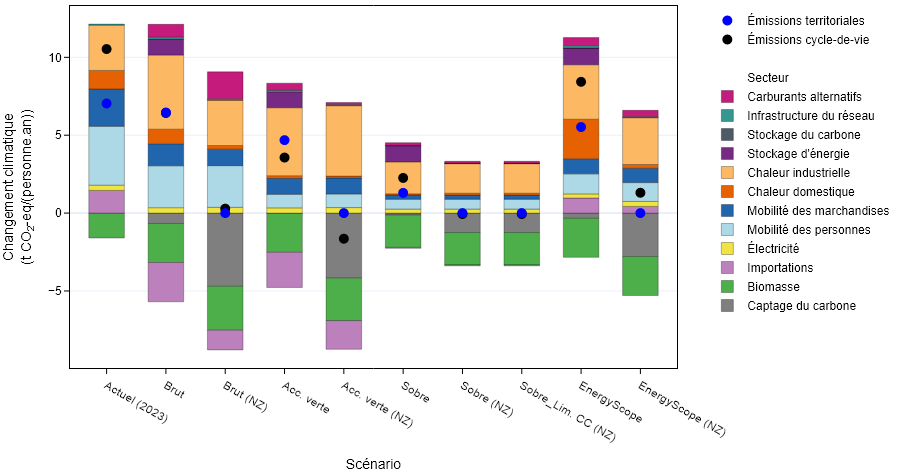

In [39]:
fig = plot_contribution_by_sector(
    df=df_total_impact,
    imp_cat='Climate change, short term, total',
    save_results=False,
    show_total_marker=False,
    show_direct_marker=False,
    show_regionalized_marker=False,
    showlegend=True,
    show_fig=False,
    x_label_name='Scénario',
    return_fig=True,
    multiple_rcp=False,
)
total_impact = df_total_impact.groupby('Run').sum().reset_index()
x = total_impact["Run"]
y = total_impact['Climate change, short term, total']
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode='markers',
        marker=dict(color="black", size=10, symbol="circle"),
        name="Émissions cycle-de-vie",
    )
)
direct_impact = df_total_impact[
    (df_total_impact['Phase'] == 'Operation (direct)')
    | ((df_total_impact['Phase'] == 'Resource') & (df_total_impact['index'].str.startswith('BIOMASS_')))
].groupby('Run').sum().reset_index()
# x = direct_impact["Run"]
# y = direct_impact['Climate change, short term, total']
# fig.add_trace(
#     go.Scatter(
#         x=x,
#         y=y,
#         mode='markers',
#         marker=dict(color="red", size=10, symbol="circle"),
#         name="Direct emissions",
#     )
# )
x = run_list
y = [results_dict[run]['territorial_GHG'] for run in run_list]
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode='markers',
        marker=dict(color="blue", size=10, symbol="circle"),
        name="Émissions territoriales",
    )
)
fig.update_xaxes(
    categoryorder='array',
    categoryarray=run_list
)
fig.update_layout(
    width=width,
    height=height,
    yaxis_title="Changement climatique<br>(t CO<sub>2</sub>-eq/(personne.an))",
)
secteurs_traduits = {
    "Alternative fuels": "Carburants alternatifs",
    'Grid infrastructure': 'Infrastructure du réseau',
    'Energy storage': "Stockage d'énergie",
    'Carbon storage': 'Stockage du carbone',
    "Industrial heat": "Chaleur industrielle",
    "Domestic heat": "Chaleur domestique",
    "Freight mobility": "Mobilité des marchandises",
    "Passenger mobility": "Mobilité des personnes",
    "Electricity": "Électricité",
    "Imports": "Importations",
    "Biomass": "Biomasse",
    "Carbon capture": "Captage du carbone",
    "Sector": "Secteur",
}
fig.for_each_trace(lambda t: t.update(
    name=secteurs_traduits.get(t.name, t.name),
    hovertemplate=(
        t.hovertemplate.replace(t.name, secteurs_traduits.get(t.name, t.name))
        if t.hovertemplate else t.hovertemplate
    )
))

fig.show()
if save_results:
    fig.write_html('../03_Results/contributions_sectors_ccst.html')

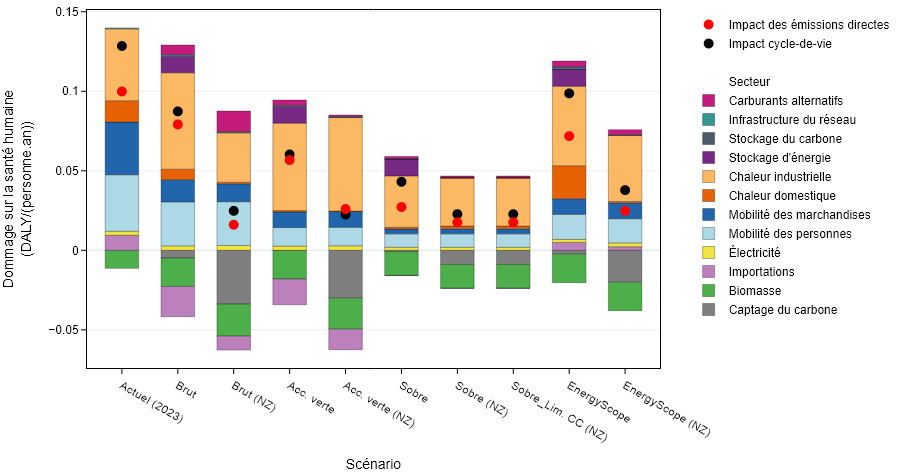

In [40]:
fig = plot_contribution_by_sector(
    df=df_total_impact.rename(columns={'Total human health (biogenic)': 'Total human health'}),
    imp_cat='Total human health',
    save_results=False,
    show_total_marker=False,
    show_direct_marker=False,
    show_regionalized_marker=False,
    showlegend=True,
    x_label_name='Scénario',
    return_fig=True,
    show_fig=False,
    multiple_rcp=False,
)
x = total_impact["Run"]
y = total_impact['Total human health (biogenic)']
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode='markers',
        marker=dict(color="black", size=10, symbol="circle"),
        name="Impact cycle-de-vie",
    )
)
x = direct_impact["Run"]
y = direct_impact['Total human health (biogenic)']
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode='markers',
        marker=dict(color="red", size=10, symbol="circle"),
        name="Impact des émissions directes",
    )
)
fig.update_xaxes(
    categoryorder='array',
    categoryarray=run_list
)
fig.update_layout(
    width=width,
    height=height,
    yaxis_title="Dommage sur la santé humaine<br>(DALY/(personne.an))",
)
fig.for_each_trace(lambda t: t.update(
    name=secteurs_traduits.get(t.name, t.name),
    hovertemplate=(
        t.hovertemplate.replace(t.name, secteurs_traduits.get(t.name, t.name))
        if t.hovertemplate else t.hovertemplate
    )
))
fig.show()
if save_results:
    fig.write_html('../03_Results/contributions_sectors_hh.html')

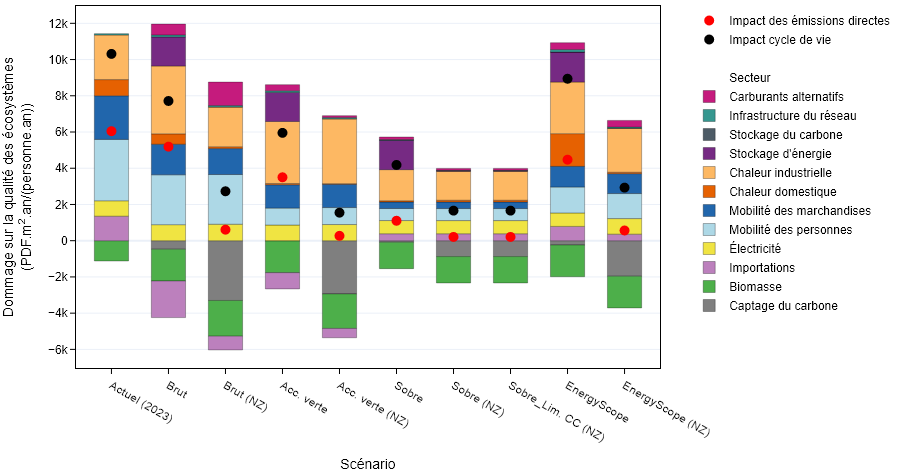

In [41]:
fig = plot_contribution_by_sector(
    df=df_total_impact.rename(columns={'Total ecosystem quality (biogenic)': 'Total ecosystem quality'}),
    imp_cat='Total ecosystem quality',
    save_results=False,
    show_total_marker=False,
    show_direct_marker=False,
    show_regionalized_marker=False,
    showlegend=True,
    x_label_name='Scénario',
    return_fig=True,
    show_fig=False,
    multiple_rcp=False,
)
x = total_impact["Run"]
y = total_impact['Total ecosystem quality (biogenic)']
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode='markers',
        marker=dict(color="black", size=10, symbol="circle"),
        name="Impact cycle de vie",
    )
)
x = direct_impact["Run"]
y = direct_impact['Total ecosystem quality (biogenic)']
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode='markers',
        marker=dict(color="red", size=10, symbol="circle"),
        name="Impact des émissions directes",
    )
)
fig.update_xaxes(
    categoryorder='array',
    categoryarray=run_list
)
fig.update_layout(
    width=width,
    height=height,
    yaxis_title="Dommage sur la qualité des écosystèmes<br>(PDF.m<sup>2</sup>.an/(personne.an))",
)
fig.for_each_trace(lambda t: t.update(
    name=secteurs_traduits.get(t.name, t.name),
    hovertemplate=(
        t.hovertemplate.replace(t.name, secteurs_traduits.get(t.name, t.name))
        if t.hovertemplate else t.hovertemplate
    )
))
fig.show()
if save_results:
    fig.write_html('../03_Results/contributions_sectors_eq.html')

## Contributions des catégories d'impact aux AoP

In [42]:
impact_categories_traduits = {
    "Human toxicity cancer, short term": "Toxicité humaine (cancer), court terme",
    "Water availability, human health": "Disponibilité de l'eau, santé humaine",
    "Human toxicity non-cancer, short term": "Toxicité humaine (non-cancer), court terme",
    "Particulate matter formation": "Formation de particules fines",
    "Other": "Autre",
    "Human toxicity non-cancer, long term": "Toxicité humaine (non-cancer), long terme",
    "Climate change, human health, short term": "Changement climatique, santé humaine, court terme",
    "Climate change, human health, long term": "Changement climatique, santé humaine, long terme",
    "Freshwater ecotoxicity, short term": "Écotoxicité de l'eau douce, court terme",
    "Marine acidification, short term": "Acidification des océans, court terme",
    "Terrestrial acidification": "Acidification terrestre",
    "Photochemical ozone formation, ecosystem quality": "Formation d'ozone photochimique, qualité des écosystèmes",
    "Marine acidification, long term": "Acidification des océans, long terme",
    "Land transformation, biodiversity": "Transformation des terres, biodiversité",
    "Land occupation, biodiversity": "Occupation des sols, biodiversité",
    "Freshwater ecotoxicity, long term": "Écotoxicité de l'eau douce, long terme",
    "Freshwater acidification": "Acidification de l'eau douce",
    "Climate change, ecosystem quality, short term": "Changement climatique, qualité des écosystèmes, court terme",
    "Climate change, ecosystem quality, long term": "Changement climatique, qualité des écosystèmes, long terme"
}

In [43]:
def plot_contrib_impact_categories(aop: str, cutoff: float = 0.0, save_results=save_results):
    df = df_total_impact[['Run', 'index', 'Phase', 'Sector'] + [
        i[2] for i in impact_categories_list if
        (i[1] == aop)
        & (i[2] not in [f'Total {aop.lower()}', f'Total {aop.lower()} (biogenic)', f'Remaining {aop.lower()}'])
        & (i[2] not in [
            f'Climate change, {aop.lower()}, short term',
            f'Climate change, {aop.lower()}, short term, total',
            f'Climate change, {aop.lower()}, long term',
            f'Climate change, {aop.lower()}, long term, total'])
    ]]
    df = df.melt(id_vars=['Run', 'index', 'Phase', 'Sector'], var_name='Impact category', value_name='Value').dropna(subset=['Value'])
    total_impact = df[['Run', 'Value']].groupby('Run').sum().reset_index()
    df['Impact category'] = df['Impact category'].str.replace(', biogenic', '')
    df['Impact category'] = df['Impact category'].str.replace(', fossil', '')
    df['Impact category'] = df['Impact category'].str.replace(', land transformation', '')
    df = df.groupby(['Run', 'Impact category'])['Value'].sum().reset_index()
    df['Impact category'] = df.apply(lambda x: 'Other' if ((x['Value'] > 0) & (x['Value'] / float(total_impact[total_impact.Run == x['Run']].Value.iloc[0]) < cutoff)) else x['Impact category'], axis=1)
    df = df.groupby(['Run', 'Impact category'])['Value'].sum().reset_index()
    df['Impact category'] = df['Impact category'].str.replace(', CO2 uptake', '')
    fig = px.bar(
        pd.concat([df[df['Impact category'] != 'Other'], df[df['Impact category'] == 'Other']]),
        x='Run',
        y='Value',
        color='Impact category',
        color_discrete_map=impact_category_colors,
        labels={
            'Value': "Dommage sur la qualité des écosystèmes<br>(PDF.m<sup>2</sup>.an/(personne.an))" if aop == 'Ecosystem quality' else "Dommage sur la santé humaine<br>(DALY/(personne.an))",
            'Run': 'Scénario',
            'Impact category': "Catégorie d'impact"
        },
        category_orders={'Run': run_list},
    ).update_layout(
        width=1000 if aop == "Human health" else 1050,
        height=550,
    )
    x = total_impact["Run"]
    y = total_impact['Value']
    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode='markers',
            marker=dict(color="black", size=10, symbol="circle"),
            name="Dommage net",
        )
    )
    fig.for_each_trace(lambda t: t.update(
        name=impact_categories_traduits.get(t.name, t.name),
        hovertemplate=(
            t.hovertemplate.replace(t.name, impact_categories_traduits.get(t.name, t.name))
            if t.hovertemplate else t.hovertemplate
        )
    ))
    fig.update_layout(legend_traceorder="reversed")
    fig.show()

    if save_results:
        fig.write_html(f'../03_Results/contributions_categories_{aop.lower().replace(" ", "_")}.html')

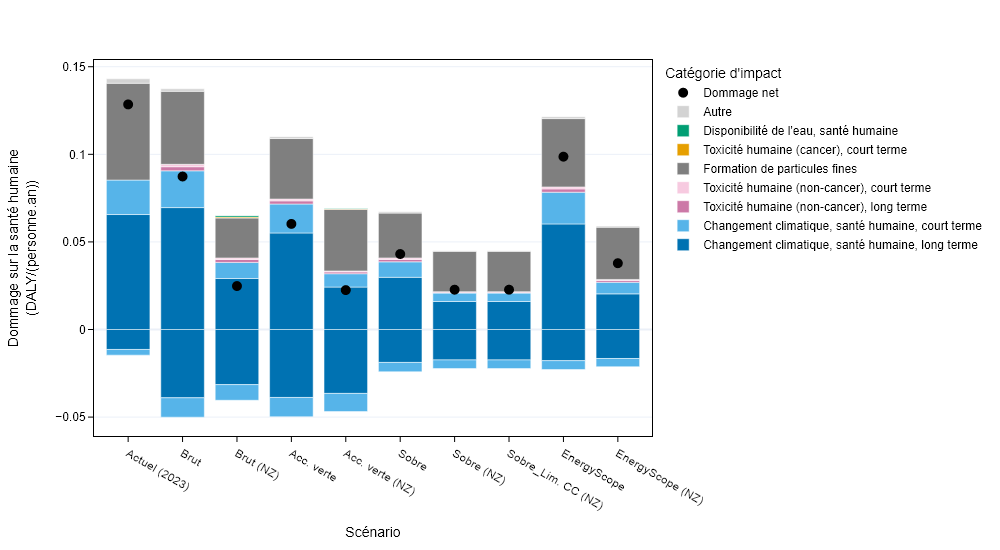

In [44]:
plot_contrib_impact_categories('Human health', cutoff=0.01)

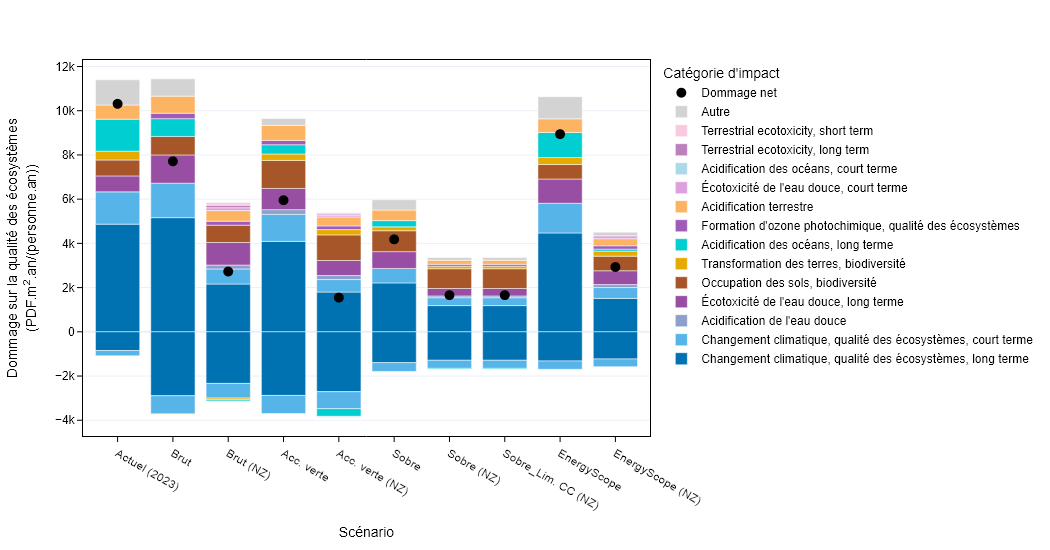

In [45]:
plot_contrib_impact_categories('Ecosystem quality', cutoff=0.03)

### Contributions des phases du cycle de vie

In [46]:
def summary_df_cat(cat):

    if cat == 'Climate change, short term, total':
        conv_factor = 1e3
    elif cat == 'Total human health (biogenic)':
        conv_factor = 1e6
    elif cat == 'Total ecosystem quality (biogenic)':
        conv_factor = 1e6
    else:
        raise ValueError('Unrecognized category')

    df_constr = df_f_mult.groupby(['Run']).agg({cat: 'sum'})
    df_constr[cat] = df_constr.apply(lambda x: x[cat] * conv_factor / N_capita_2023 if x.name == 'Actuel (2023)' else x[cat] * conv_factor / N_capita_2050, axis=1)
    df_constr.rename(columns={cat: 'Construction'}, inplace=True)

    df_op = df_annual_prod.groupby(['Run']).agg({cat: 'sum'})
    df_op[cat] = df_op.apply(lambda x: x[cat] * conv_factor / N_capita_2023 if x.name == 'Actuel (2023)' else x[cat] * conv_factor / N_capita_2050, axis=1)
    df_op.rename(columns={cat: 'Operation'}, inplace=True)

    df_op_direct = df_annual_prod_direct.groupby(['Run']).agg({cat: 'sum'})
    df_op_direct[cat] = df_op_direct.apply(lambda x: x[cat] * conv_factor / N_capita_2023 if x.name == 'Actuel (2023)' else x[cat] * conv_factor / N_capita_2050, axis=1)
    df_op_direct.rename(columns={cat: 'Operation (direct)'}, inplace=True)

    df_res = df_annual_res.groupby(['Run']).agg({cat: 'sum'})
    df_res[cat] = df_res.apply(lambda x: x[cat] * conv_factor / N_capita_2023 if x.name == 'Actuel (2023)' else x[cat] * conv_factor / N_capita_2050, axis=1)
    df_res.rename(columns={cat: 'Resource'}, inplace=True)

    df = pd.concat([df_constr, df_op, df_op_direct, df_res], axis=1).fillna(0)

    df['Operation (indirect)'] = df['Operation'] - df['Operation (direct)']
    df['Total'] = df['Construction'] + df['Operation'] + df['Resource']
    df = df.reset_index()

    return df

In [47]:
df_ccst = summary_df_cat('Climate change, short term, total')
df_hh = summary_df_cat('Total human health (biogenic)')
df_eq = summary_df_cat('Total ecosystem quality (biogenic)')

In [48]:
phase_traduites = {
    'Operation (direct)': 'Opération (émissions directes)',
    'Operation (indirect)': 'Opération (émissions indirectes)',
    'Construction': 'Infrastructures',
    'Resource': 'Importations',
}

In [49]:
def plot_contrib_phase(df, cat, save_results=save_results):

    if cat == 'ccst':
        label = 'Changement climatique (t CO<sub>2</sub>-eq./(personne.an))'
    elif cat == 'hh':
        label = 'Dommage sur la santé humaine (DALY/(personne.an))'
    else:
        label = 'Dommage sur la qualité des écosystèmes (PDF.m<sup>2</sup>.an/(personne.an))'

    fig = px.bar(
        df,
        orientation='h',
        y='Run',
        x=['Construction', 'Operation (indirect)', 'Operation (direct)', 'Resource'],
        labels={
            'value': label,
            'Run': 'Scénario',
            'variable': 'Phase du cycle de vie',
        },
        category_orders={'Run': run_list},
    )
    y = df["Run"]
    x = df['Total']
    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode='markers',
            marker=dict(color="black", size=10, symbol="circle"),
            name="Impact cycle-de-vie",
        )
    )
    fig.update_layout(width=900, height=400 if not add_group_scenarios else 700)
    fig.for_each_trace(lambda t: t.update(name = phase_traduites.get(t.name, t.name)))
    fig.show()
    if save_results:
        fig.write_html(f'../03_Results/contributions_phases_{cat}.html')

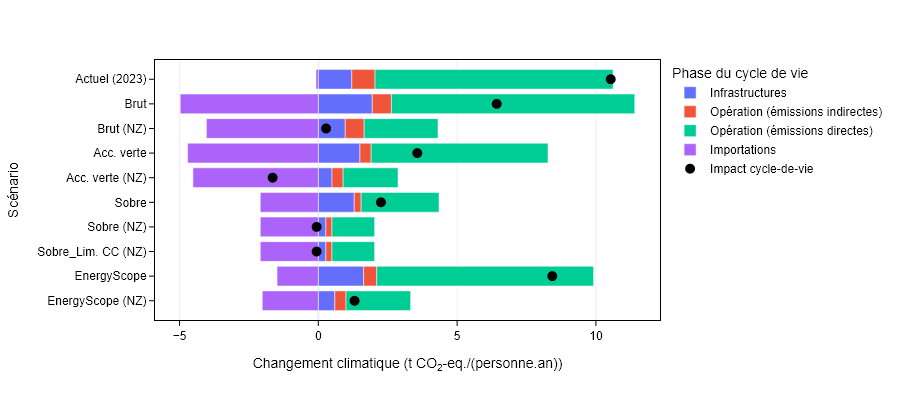

In [50]:
plot_contrib_phase(df_ccst, 'ccst')

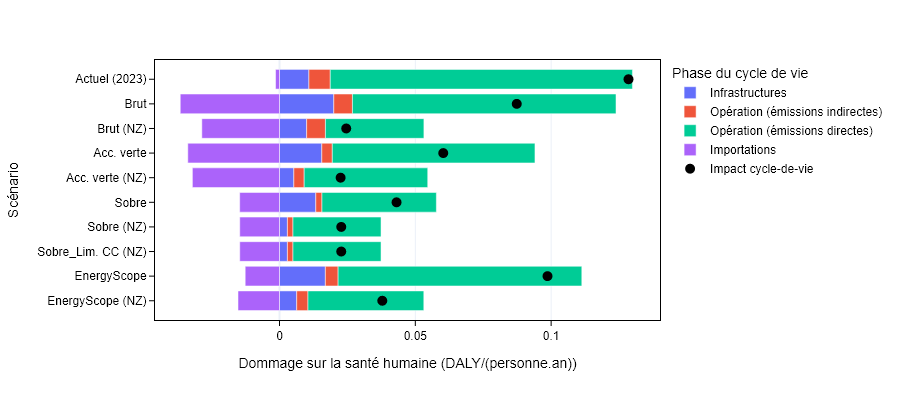

In [51]:
plot_contrib_phase(df_hh, 'hh')

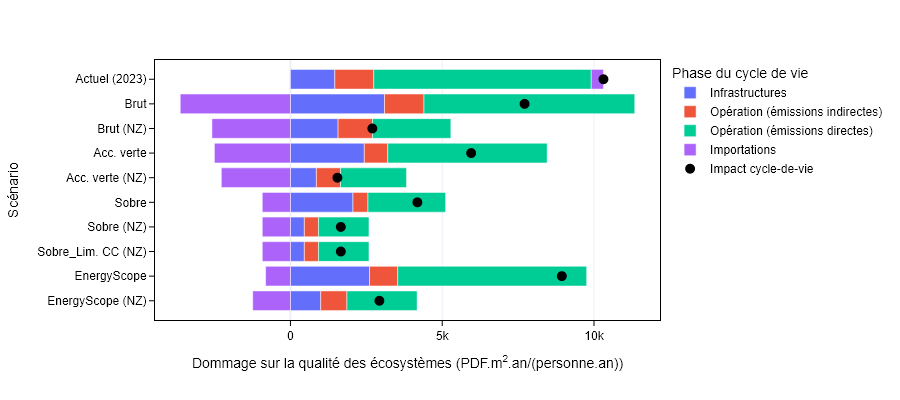

In [52]:
plot_contrib_phase(df_eq, 'eq')

## Coûts du système

In [53]:
cost = []
for run in run_list:
    cost.append([run] + [i/1000 for i in results_dict[run]['results'].postprocessing['df_annual'][['C_maint', 'C_op', 'C_inv_an']].sum().tolist()])
df_cost = pd.DataFrame(cost, columns=['Scenario', 'Coûts de maintenance', "Coûts d'opération", "Coûts d'investissement annualisés"])

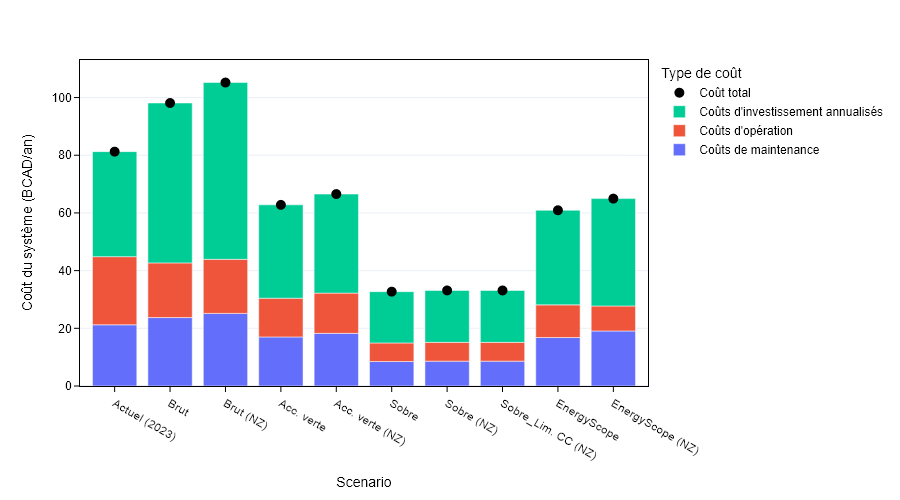

In [54]:
fig = px.bar(
    df_cost.melt(id_vars='Scenario', var_name='Type de coût', value_name='Coût du système (BCAD/an)'),
    x='Scenario',
    y='Coût du système (BCAD/an)',
    color='Type de coût',
    category_orders={'Scenario': run_list},
).update_layout(width=900, height=500, legend_traceorder="reversed")

x = df_cost['Scenario']
y = df_cost[['Coûts de maintenance', "Coûts d'opération", "Coûts d'investissement annualisés"]].sum(axis=1)
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode='markers',
        marker=dict(color="black", size=10, symbol="circle"),
        name="Coût total",
    )
)

fig.show()

if save_results:
    fig.write_html('../03_Results/costs_system.html')

## Sankey des flux de CO2-eq

In [55]:
def plot_carbon_sankey(df_flow):
    node = np.unique(np.concatenate((df_flow['source (FR)'].unique(), df_flow['target (FR)'].unique())))
    df_sankey = df_flow.replace(node, range(len(node)))

    # Plotting
    opacity = 0.5

    fig = go.Figure(data=[go.Sankey(
        valueformat=".2f",
        valuesuffix="",
        node=dict(
            pad=15,
            thickness=15,
            line=dict(color="black", width=0.5),
            label=node,
            color="#DCDCDC"
        ),
        link=dict(
            source=df_sankey['source (FR)'],
            target=df_sankey['target (FR)'],
            value=df_sankey['value'],
            label=df_sankey['value'],
            # color=df_sankey['color'].apply(lambda c: Color(c).rgba(opacity))
        )
    )])
    fig.update_layout(
        title_text="Diagramme de Sankey des émissions de gaz à effet de serre (Mt CO2-eq/an)",
        font_size=10,
        template="plotly",
        font_color="black",
    )

    return fig

In [56]:
for run in df_total_impact.Run.unique():
    df_flow = plot_sankey_carbon_flows(
        run=run,
        df_total_impact=df_total_impact,
        model=model,
        cutoff=0,
        aggregate_technologies=True,
        show_figure=False,
        save_results=False,
        per_capita=False,
        mode='mfa',
        return_figure=False,
        return_df=True,
    )

    df_flow['source (FR)'] = df_flow.apply(lambda x: es_tech_name_dict_trad_to_fr[x['source']] if x['source'] in es_tech_name_dict_trad_to_fr else x['source'], axis=1)
    df_flow['target (FR)'] = df_flow.apply(lambda x: es_tech_name_dict_trad_to_fr[x['target']] if x['target'] in es_tech_name_dict_trad_to_fr else x['target'], axis=1)

    fig = plot_carbon_sankey(df_flow)

    if save_results:
        fig.write_html(f'../03_Results/sankey_carbon_flows_{run.lower().replace(" (nz)", "_nz").replace(" (2023)", "").replace(". ", "_")}.html')

C:\Users\matth\PycharmProjects\EnergyScope-Quebec\projects\lca\02_Regionalization\01_Notebooks\utils.py:2862: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



## Quelques chiffres sur les différentes configurations obtenues

In [57]:
for distance_level in ['_SD', '_MD', '_LD', '_ELD']:
    model['Name'] = model['Name'].str.replace(distance_level, '')
    model['Flow'] = model['Flow'].str.replace(distance_level, '')
    df_total_impact['index'] = df_total_impact['index'].str.replace(distance_level, '')
model.drop_duplicates(inplace=True)

model['Name'] = model['Name'].replace(es_tech_name_dict)
df_total_impact['index'] = df_total_impact['index'].replace(es_tech_name_dict)

### Capture de carbone

In [58]:
cc_techs = list(results_dict[run_list[0]]['results'].sets['TECHNOLOGIES_OF_CC']['TECHNOLOGIES_OF_CC'])
df_carbon_capture = df_annual_prod[(df_annual_prod['index'].isin(cc_techs)) & (df_annual_prod['Annual_Prod'] > 0)][['Run', 'index', 'Annual_Prod']].reset_index(drop=True)
df_carbon_capture['Annual_Prod'] *= 1e-3  # conver kt CO2 to Mt CO2

In [59]:
df_carbon_capture

,Run,index,Annual_Prod
0,Brut,CARBON_CAPTURE_MEMBRANES,6.635811
1,Brut (NZ),CARBON_CAPTURE_MEMBRANES,42.648465
2,Brut (NZ),DAC_HT,2.000000
3,Brut (NZ),DAC_LT,2.000000
4,Acc. verte,CARBON_CAPTURE_MEMBRANES,0.174575
5,Acc. verte (NZ),CARBON_CAPTURE_MEMBRANES,41.371245
6,Sobre,CARBON_CAPTURE_MEMBRANES,1.213362
7,Sobre (NZ),CARBON_CAPTURE_MEMBRANES,12.353256
8,Sobre_Lim. CC (NZ),CARBON_CAPTURE_MEMBRANES,12.353256
9,EnergyScope,CARBON_CAPTURE_MEMBRANES,3.338492


### Emissions de GES

In [60]:
df_ccst.set_index('Run').T

Run,Acc. verte,Acc. verte (NZ),Actuel (2023),Brut,Brut (NZ),EnergyScope,EnergyScope (NZ),Sobre,Sobre (NZ),Sobre_Lim. CC (NZ)
Construction,1.498957,0.493461,1.203976,1.943449,0.968785,1.633228,0.595277,1.294659,0.272217,0.272217
Operation,6.773279,2.377072,9.412903,9.454883,3.342590,8.280540,2.729200,3.053307,1.755949,1.755949
Operation (direct),6.368296,1.977042,8.572947,8.766139,2.659213,7.809695,2.326334,2.804486,1.537369,1.537369
Resource,-4.707069,-4.516395,-0.084505,-4.973709,-4.031779,-1.485602,-2.019290,-2.090837,-2.089740,-2.089740
Operation (indirect),0.404983,0.400029,0.839955,0.688744,0.683377,0.470845,0.402867,0.248821,0.218580,0.218580
Total,3.565167,-1.645862,10.532373,6.424622,0.279596,8.428166,1.305188,2.257129,-0.061574,-0.061574


In [61]:
df_ccst_rel_2023 = df_ccst.set_index('Run').T
for col in [i for i in df_ccst_rel_2023.columns if i != 'Actuel (2023)']:
    df_ccst_rel_2023[col] = 100 * (df_ccst_rel_2023[col] - df_ccst_rel_2023['Actuel (2023)']) / df_ccst_rel_2023['Actuel (2023)']
df_ccst_rel_2023.drop(columns=['Actuel (2023)'], inplace=True)

In [62]:
df_ccst_rel_2023

Run,Acc. verte,Acc. verte (NZ),Brut,Brut (NZ),EnergyScope,EnergyScope (NZ),Sobre,Sobre (NZ),Sobre_Lim. CC (NZ)
Construction,24.500609,-59.014001,61.419284,-19.534511,35.652929,-50.557360,7.531996,-77.390146,-77.390146
Operation,-28.042611,-74.746668,0.445987,-64.489276,-12.029901,-71.005750,-67.562537,-81.345293,-81.345293
Operation (direct),-25.716379,-76.938593,2.253501,-68.981346,-8.903037,-72.864249,-67.286790,-82.067206,-82.067206
Resource,5470.143645,5244.508330,5785.674608,4671.034348,1657.998147,2289.541325,2374.206689,2372.909101,2372.909101
Operation (indirect),-51.785146,-52.374933,-18.002286,-18.641280,-43.944020,-52.037108,-70.376926,-73.977141,-73.977141
Total,-66.150390,-115.626696,-39.001186,-97.345366,-19.978473,-87.607846,-78.569605,-100.584613,-100.584613


### Mobilité électrique

In [63]:
df_annual_prod = aggregate_mobility_submodels(df_annual_prod)

In [64]:
df_mob_elec = df_annual_prod[df_annual_prod['index'].isin(['CAR_EV', 'SUV_EV'])][['Run', 'index', 'Annual_Prod']].reset_index(drop=True)
df_mob_elec['Total EUD'] = df_mob_elec.apply(lambda x: results_dict[x['Run']]['results'].parameters['end_uses_demand_year'].loc[['MOBILITY_PASSENGER_SD', 'MOBILITY_PASSENGER_MD', 'MOBILITY_PASSENGER_LD']]['end_uses_demand_year'].sum(), axis=1)
df_mob_elec['Pourcentage du total'] = 100 * df_mob_elec['Annual_Prod'] / df_mob_elec['Total EUD']

In [65]:
df_mob_elec

,Run,index,Annual_Prod,Total EUD,Pourcentage du total
0,Acc. verte,CAR_EV,48011.732912,113287.155000,42.380562
1,Acc. verte (NZ),CAR_EV,48011.732912,113287.155000,42.380562
2,Actuel (2023),CAR_EV,1749.010034,183004.830000,0.955718
3,EnergyScope,CAR_EV,109972.117194,179210.862262,61.364649
4,EnergyScope (NZ),CAR_EV,117311.671425,179210.862262,65.460134
5,Sobre,CAR_EV,40512.761130,84791.153400,47.779467
6,Sobre (NZ),CAR_EV,40512.761130,84791.153400,47.779467
7,Sobre_Lim. CC (NZ),CAR_EV,40512.761130,84791.153400,47.779467
8,Acc. verte,SUV_EV,12002.933228,113287.155000,10.595140
9,Acc. verte (NZ),SUV_EV,12002.933228,113287.155000,10.595140


## Configurations énergétiques

In [66]:
df_annual_prod['index'] = df_annual_prod['index'].replace(es_tech_name_dict)

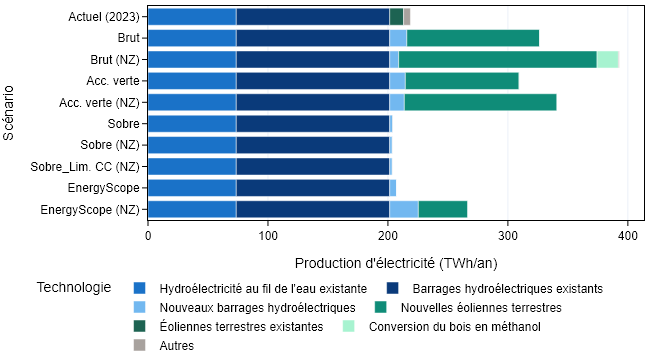

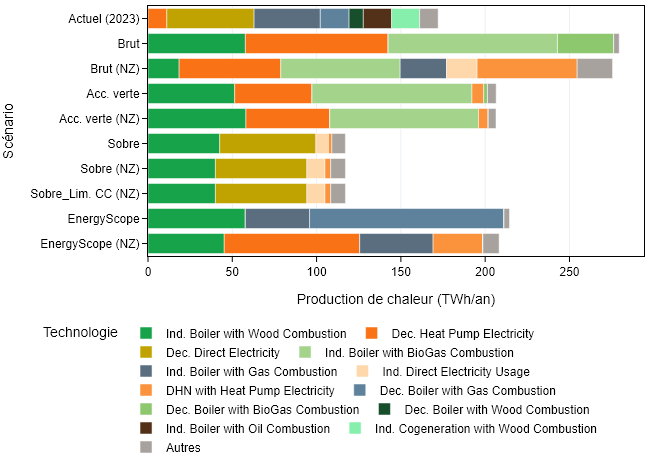

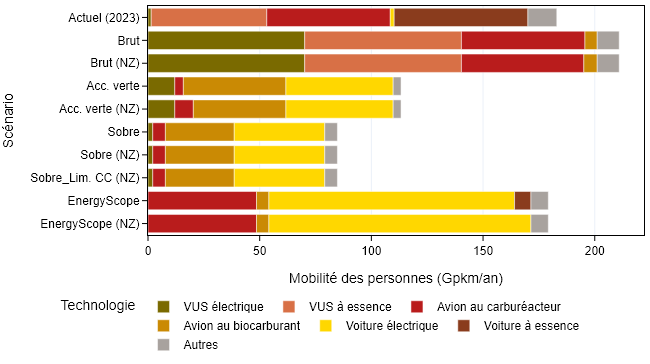

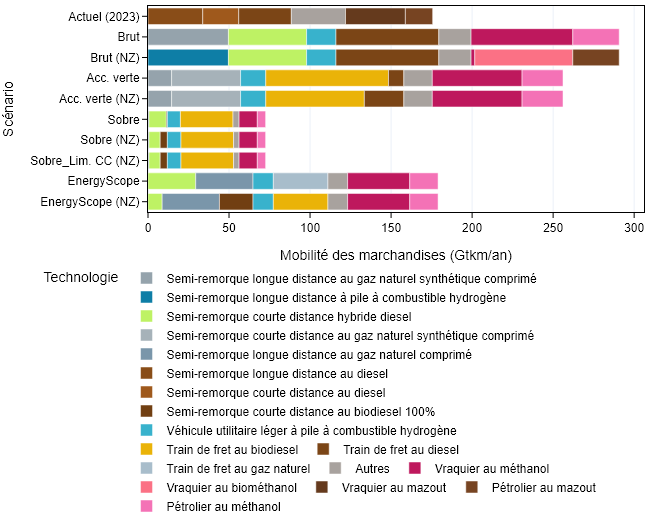

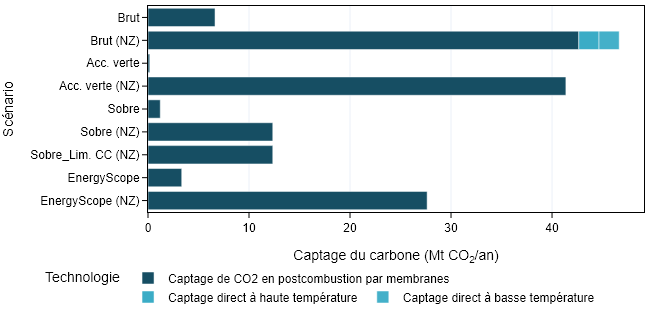

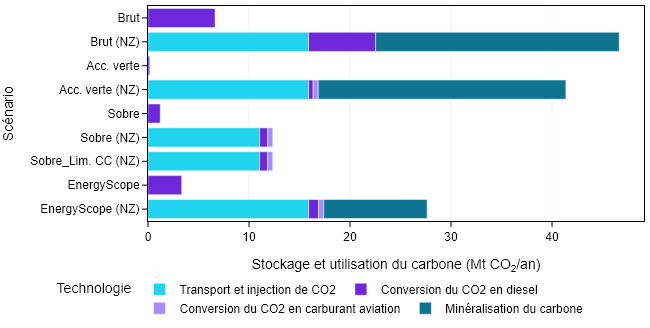

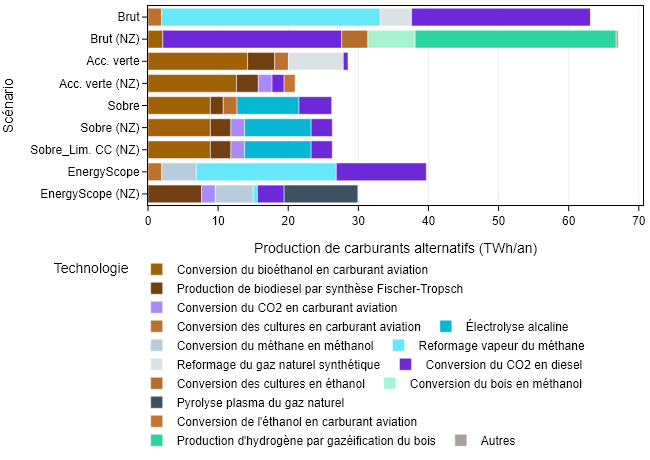

In [68]:
for sector in ['Electricity', 'Heat', 'Passenger mobility', 'Freight mobility', 'Carbon capture', 'Carbon storage and utilization', 'Other']:
    fig = plot_configuration_sector(
        model=model,
        annual_prod=df_annual_prod,
        annual_prod_2023=df_annual_prod[df_annual_prod['Run'] == 'Actuel (2023)'],
        sector=sector,
        save_results=False,
        scenario=True,
        return_fig=True,
        show_fig=False,
        cutoff=0.09 if sector in ['Freight mobility'] else (0.04 if sector in ['Electricity', 'Heat', 'Passenger mobility', 'Other'] else 0),
    )

    if sector == 'Electricity':
        fig.update_layout(xaxis_title="Production d'électricité (TWh/an)")
    elif sector == 'Heat':
        fig.update_layout(xaxis_title="Production de chaleur (TWh/an)")
    elif sector == 'Passenger mobility':
        fig.update_layout(xaxis_title="Mobilité des personnes (Gpkm/an)")
    elif sector == 'Freight mobility':
        fig.update_layout(xaxis_title="Mobilité des marchandises (Gtkm/an)")
    elif sector == 'Carbon capture':
        fig.update_layout(xaxis_title="Captage du carbone (Mt CO<sub>2</sub>/an)")
    elif sector == 'Carbon storage and utilization':
        fig.update_layout(xaxis_title="Stockage et utilisation du carbone (Mt CO<sub>2</sub>/an)")
    elif sector == 'Other':
        fig.update_layout(xaxis_title="Production de carburants alternatifs (TWh/an)")

    fig.for_each_trace(lambda t: t.update(
        name=es_tech_name_dict_trad_to_fr.get(t.name, t.name),
        hovertemplate=(
            t.hovertemplate.replace(t.name, es_tech_name_dict_trad_to_fr.get(t.name, t.name))
            if t.hovertemplate else t.hovertemplate
        )
    ))

    fig.show()

    if save_results:
        fig.write_html(f'../03_Results/configuration_{sector.lower().replace(" ", "_")}.html')